<a href="https://colab.research.google.com/github/Zeldano118/QPon_NLP_PBA/blob/main/assignments/week%204/3_week4_tfidf_custom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4: Custom TF-IDF Implementation — QPon Reviews
Using the TFIDF class from [Wittline/tf-idf](https://github.com/Wittline/tf-idf) on QPon app review data.

**Input:** `df_qpon_rev.csv`

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from collections import Counter
import scipy.sparse as sp
from numpy.linalg import norm

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

---
## TFIDF Class
From https://github.com/Wittline/tf-idf/blob/main/code/TFIDF.py — modified for Indonesian stopwords.

In [ ]:
class TFIDF(object):

    def __init__(self, corpus, lang='indonesian'):
        self.corpus = corpus
        self.norm_corpus = None
        self.lang = lang

    def __normalize_corpus(self, d):
        stop_words = nltk.corpus.stopwords.words(self.lang)
        d = re.sub(r'[^a-zA-Z0-9\s]', '', d, flags=re.I|re.A)
        d = d.lower().strip()
        tks = nltk.word_tokenize(d)
        f_tks = [t for t in tks if t not in stop_words]
        return ' '.join(f_tks)

    def preprocessing_text(self):
        n_c = np.vectorize(self.__normalize_corpus)
        self.norm_corpus = n_c(self.corpus)

    def tf(self):
        words_array = [doc.split() for doc in self.norm_corpus]
        words = list(set([word for words in words_array for word in words]))
        features_dict = {w: 0 for w in words}
        tf = []
        for doc in self.norm_corpus:
            bowf_doc = Counter(doc.split())
            all_f = Counter(features_dict)
            bowf_doc.update(all_f)
            tf.append(bowf_doc)
        return pd.DataFrame(tf)

    def df(self, tf):
        df = np.diff(sp.csc_matrix(tf, copy=True).indptr)
        df = 1 + df
        return df

    def idf(self, df):
        N = 1 + len(self.norm_corpus)
        idf = 1.0 + np.log(float(N) / df)
        idf_d = sp.spdiags(idf, diags=0, m=len(df), n=len(df)).todense()
        return idf, idf_d

    def tfidf(self, tf, idf):
        tf = np.array(tf, dtype='float64')
        tfidf = tf * idf
        norms = norm(tfidf, axis=1)
        return tfidf / norms[:, None]

---
## Load QPon Data

In [ ]:
from google.colab import files
uploaded = files.upload()

import io
for fn in uploaded.keys():
    df = pd.read_csv(io.BytesIO(uploaded[fn]))
    print(f'Loaded: {len(df):,} rows')

Saving df_qpon_rev.csv to df_qpon_rev.csv
Loaded: 4,684 rows


In [ ]:
# take a sample (full dataset is too large for dense TF-IDF matrix)
sample = df['content'].dropna().head(100).values
print(f'Using {len(sample)} reviews')

Using 100 reviews


---
## Run TF-IDF Pipeline

In [ ]:
model = TFIDF(sample, lang='indonesian')
model.preprocessing_text()
print('Preprocessing done')
print('Sample normalized:', model.norm_corpus[:3])

Preprocessing done
Sample normalized: ['login alasan aktivitas mencurigakan cs template solusi sayang disayangkan review web protes terkait login solusi dr cs perbaikan apps krusial kek mbanking ewallet sj ga seribet tinggal verifikasi ulang sesuai dah beres'
 'aplikasi log out pas login ulang gabisa alasan aktivitas mencurigakan gapernah login device baca review case penyelesaian cs solusi yg berdasarkan sistem sistem yg manusi gabisa meintenance sistemkalian dg tunggu 3x24 jam login ulang sdh uninistal login ulang sdh berbulan nihil'
 'kapok deh doang enak sekarang2 order aja susah bgt alasannya produk habis jaringan pembeli gak easy user komplen cs slowrespon gak dapet solusi habis pas dipake distasiun buka aplikasinya susah pikir2 deh pake aplikasi']


In [ ]:
# Term Frequency
tf_matrix = model.tf()
print(f'TF matrix: {tf_matrix.shape}')
tf_matrix.iloc[:5, :10]

TF matrix: (100, 993)


,login,alasan,aktivitas,mencurigakan,cs,template,solusi,sayang,disayangkan,review
0,2,1,1,1,2,1,2,1,1,1
1,4,1,1,1,1,0,1,0,0,1
2,0,0,0,0,1,0,1,0,0,0
3,2,0,0,0,1,2,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0


In [ ]:
# Document Frequency
df_vals = model.df(tf_matrix)
print(f'DF values: {len(df_vals)} terms')
print('First 10:', df_vals[:10])

DF values: 993 terms
First 10: [18  5  6  6 23  5 12  3  2  3]


In [ ]:
# IDF
idf_vals, idf_matrix = model.idf(df_vals)
print(f'IDF matrix: {idf_matrix.shape}')
print('First 10 IDF values:', idf_vals[:10])

IDF matrix: (993, 993)
First 10 IDF values: [2.72474876 4.0056826  3.82336105 3.82336105 2.4796263  4.0056826
 3.13021387 4.51650823 4.92197334 4.51650823]


In [ ]:
# TF-IDF
tfidf_matrix = model.tfidf(tf_matrix, idf_matrix)
print(f'TF-IDF matrix: {tfidf_matrix.shape}')

tfidf_df = pd.DataFrame(tfidf_matrix, columns=tf_matrix.columns)
tfidf_df.iloc[:5, :10]

TF-IDF matrix: (100, 993)


,login,alasan,aktivitas,mencurigakan,cs,template,solusi,sayang,disayangkan,review
0,0.217994,0.160238,0.152944,0.152944,0.198383,0.160238,0.250434,0.180672,0.196892,0.180672
1,0.359740,0.132214,0.126197,0.126197,0.081844,0.000000,0.103318,0.000000,0.000000,0.149075
2,0.000000,0.000000,0.000000,0.000000,0.097311,0.000000,0.122843,0.000000,0.000000,0.000000
3,0.181395,0.000000,0.000000,0.000000,0.082538,0.266671,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.069698,0.000000,0.000000,0.000000,0.000000,0.000000


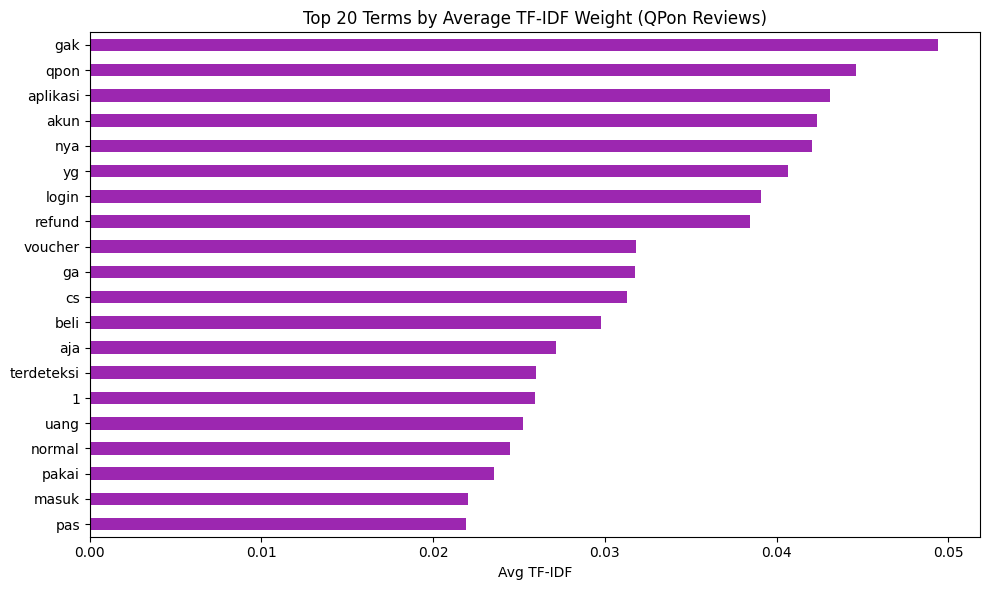

In [ ]:
import matplotlib.pyplot as plt

# top terms by average TF-IDF weight
avg_tfidf = tfidf_df.mean().sort_values(ascending=False).head(20)

avg_tfidf.plot.barh(figsize=(10, 6), color='#9C27B0')
plt.title('Top 20 Terms by Average TF-IDF Weight (QPon Reviews)')
plt.xlabel('Avg TF-IDF')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()